### Домашнє завдання: Кластеризація в Аналізі Персоналій Клієнтів

#### Контекст
В цьому ДЗ ми скористаємось алгоритмами кластеризації для задачі аналізу портретів клієнтів (Customer Personality Analysis).

Customer Personality Analysis - це аналіз різних сегментів клієнтів компанії. Цей аналіз дозволяє бізнесу краще розуміти своїх клієнтів і полегшує процес адаптації продуктів під конкретні потреби, поведінку та інтереси різних типів клієнтів.

Аналіз портретів клієнтів допомагає бізнесу змінювати свій продукт на основі цільової аудиторії, розділеної на різні сегменти. Наприклад, замість того, щоб витрачати гроші на маркетинг нового продукту для всіх клієнтів у базі даних компанії, бізнес може проаналізувати, який сегмент клієнтів найімовірніше придбає продукт, і потім зосередити маркетингові зусилля лише на цьому сегменті.

#### Завдання
На основі наданих даних в файлі `marketing_campaign.csv` потрібно виконати кластеризацію, щоб виявити сегменти клієнтів.

#### Вхідні дані
Вам надано набір даних з такими атрибутами:

**Характеристики користувачів:**
- `ID`: Унікальний ідентифікатор клієнта
- `Year_Birth`: Рік народження клієнта
- `Education`: Рівень освіти клієнта
- `Marital_Status`: Сімейний стан клієнта
- `Income`: Річний дохід домогосподарства клієнта
- `Kidhome`: Кількість дітей у домогосподарстві клієнта
- `Teenhome`: Кількість підлітків у домогосподарстві клієнта
- `Dt_Customer`: Дата реєстрації клієнта у компанії
- `Recency`: Кількість днів з моменту останньої покупки клієнта
- `Complain`: 1, якщо клієнт скаржився за останні 2 роки, 0 - якщо ні

**Продукти:**
- `MntWines`: Сума, витрачена на вино за останні 2 роки
- `MntFruits`: Сума, витрачена на фрукти за останні 2 роки
- `MntMeatProducts`: Сума, витрачена на м'ясні продукти за останні 2 роки
- `MntFishProducts`: Сума, витрачена на рибні продукти за останні 2 роки
- `MntSweetProducts`: Сума, витрачена на солодощі за останні 2 роки
- `MntGoldProds`: Сума, витрачена на золото за останні 2 роки

**Акції:**
- `NumDealsPurchases`: Кількість покупок, зроблених з використанням знижок
- `AcceptedCmp1`: 1, якщо клієнт прийняв пропозицію у першій кампанії, 0 - якщо ні
- `AcceptedCmp2`: 1, якщо клієнт прийняв пропозицію у другій кампанії, 0 - якщо ні
- `AcceptedCmp3`: 1, якщо клієнт прийняв пропозицію у третій кампанії, 0 - якщо ні
- `AcceptedCmp4`: 1, якщо клієнт прийняв пропозицію у четвертій кампанії, 0 - якщо ні
- `AcceptedCmp5`: 1, якщо клієнт прийняв пропозицію у п'ятій кампанії, 0 - якщо ні
- `Response`: 1, якщо клієнт прийняв пропозицію в останній кампанії, 0 - якщо ні

**Взаємодія з компанією:**
- `NumWebPurchases`: Кількість покупок, зроблених через вебсайт компанії
- `NumCatalogPurchases`: Кількість покупок, зроблених за каталогом
- `NumStorePurchases`: Кількість покупок, зроблених безпосередньо у магазинах
- `NumWebVisitsMonth`: Кількість відвідувань вебсайту компанії за останній місяць


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.cm as cm
import plotly.express as px
import matplotlib.pyplot as plt


from sklearn.cluster import KMeans, DBSCAN
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

pd.set_option('display.max.columns', 130)

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


**Завдання 1**. Завантажте дані з `marketing_campaign.csv` в Pandas dataframe і виведіть основну інформацію про дані: скільки всього рядків і колонок, які типи даних мають колонки, скільки пропущених значень.

In [3]:
df = pd.read_csv('drive/MyDrive/Colab Notebooks/data/marketing_campaign.csv', sep='\t')

In [4]:
df.shape

(2240, 29)

In [5]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2240 entries, 0 to 2239
Data columns (total 29 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   ID                   2240 non-null   int64  
 1   Year_Birth           2240 non-null   int64  
 2   Education            2240 non-null   object 
 3   Marital_Status       2240 non-null   object 
 4   Income               2216 non-null   float64
 5   Kidhome              2240 non-null   int64  
 6   Teenhome             2240 non-null   int64  
 7   Dt_Customer          2240 non-null   object 
 8   Recency              2240 non-null   int64  
 9   MntWines             2240 non-null   int64  
 10  MntFruits            2240 non-null   int64  
 11  MntMeatProducts      2240 non-null   int64  
 12  MntFishProducts      2240 non-null   int64  
 13  MntSweetProducts     2240 non-null   int64  
 14  MntGoldProds         2240 non-null   int64  
 15  NumDealsPurchases    2240 non-null   i

In [7]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
Income,24


**Завдання 2.** Заповніть пропущені значення з врахуванням того завдання (кластеризація), яке ми виконуємо. Поясніть свій вибір заповнення пропущених значень.

In [8]:
print(f'There are {df.Income.isnull().sum()} missing values in column Income')
print(f'The percent of missing Income values: {df.Income.isnull().sum()/df.shape[0]*100:.2f}')

There are 24 missing values in column Income
The percent of missing Income values: 1.07


In [9]:
df.Income.describe()

,Income
count,2216.000000
mean,52247.251354
std,25173.076661
min,1730.000000
25%,35303.000000
50%,51381.500000
75%,68522.000000
max,666666.000000


In [10]:
print(f'Mean value:   {df.Income.mean():.2f}')
print(f'Median value: {df.Income.median()}')
print(f'Mode value:   {df.Income.mode()[0]}')

Mean value:   52247.25
Median value: 51381.5
Mode value:   7500.0


`Median` and `mode` are quite similar, but because of the outliers & skewness, the `median` is more reliable here.

In [11]:
df['Income'] = df['Income'].fillna(df['Income'].median())

In [12]:
df.isnull().sum()[df.isnull().sum() > 0]

,0


**Завдання 3.** У нас є декілька колонок з категоріальними значеннями та одна колонка з датою. Як би ви обробили ці колонки для того, аби передати їх в алгоритм кластеризації?

Реалізуйте обробку категоріальних колонок і колонки з датою та перетворіть їх на ознаки, корисні для кластеризації з вашого погляду.

In [13]:
df.select_dtypes('object')

,Education,Marital_Status,Dt_Customer
0,Graduation,Single,04-09-2012
1,Graduation,Single,08-03-2014
2,Graduation,Together,21-08-2013
3,Graduation,Together,10-02-2014
4,PhD,Married,19-01-2014
...,...,...,...
2235,Graduation,Married,13-06-2013
2236,PhD,Together,10-06-2014
2237,Graduation,Divorced,25-01-2014
2238,Master,Together,24-01-2014


Dataset includes two categorical columns: `Education` and `Marital_Status`    
and one column with date: `Dt_Customer`

Clustering works on numerical features, so categorical variables need to be handled.

In [14]:
df['Education'].value_counts()

,count
Education,
Graduation,1127
PhD,486
Master,370
2n Cycle,203
Basic,54


In [15]:
df['Marital_Status'].value_counts()

,count
Marital_Status,
Married,864
Together,580
Single,480
Divorced,232
Widow,77
Alone,3
Absurd,2
YOLO,2


In [16]:
education_enc = pd.get_dummies(df['Education'], prefix='Education', dtype='int')
education_enc.head()

,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD
0,0,0,1,0,0
1,0,0,1,0,0
2,0,0,1,0,0
3,0,0,1,0,0
4,0,0,0,0,1


Let's combine options `Alone`, `Absurd`, `YOLO` to `Other` since there are only few values of each of them.

In [17]:
df['Marital_Status'] = df['Marital_Status'].replace(
    ['Alone', 'Absurd', 'YOLO'], 'Other'
)

In [18]:
mar_status_enc = pd.get_dummies(df['Marital_Status'], prefix='Marital_Status', dtype='int')
mar_status_enc.head()

,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Other,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow
0,0,0,0,1,0,0
1,0,0,0,1,0,0
2,0,0,0,0,1,0
3,0,0,0,0,1,0
4,0,1,0,0,0,0


In [19]:
df = pd.concat([df, education_enc, mar_status_enc], axis=1)
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Other,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow
0,5524,1957,Graduation,Single,58138.0,0,0,04-09-2012,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,0,0,1,0,0,0,0,0,1,0,0
1,2174,1954,Graduation,Single,46344.0,1,1,08-03-2014,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,0,0,1,0,0,0,0,0,1,0,0
2,4141,1965,Graduation,Together,71613.0,0,0,21-08-2013,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,0,0,1,0,0,0,0,0,0,1,0
3,6182,1984,Graduation,Together,26646.0,1,0,10-02-2014,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,0,0,1,0,0,0,0,0,0,1,0
4,5324,1981,PhD,Married,58293.0,1,0,19-01-2014,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,0,0,0,0,1,0,1,0,0,0,0


In [20]:
df['Dt_Customer'].value_counts()

,count
Dt_Customer,
31-08-2012,12
12-05-2014,11
14-02-2013,11
12-09-2012,11
22-05-2014,10
...,...
01-11-2013,1
10-08-2013,1
11-10-2012,1


#### Dt_Customer

Lets create new columns based on `Dt_Customer`

In [21]:
df['Dt_Customer'] = pd.to_datetime(df['Dt_Customer'], format='%d-%m-%Y')

In [22]:
df['Dt_Customer_Day'] = df['Dt_Customer'].dt.day
df['Dt_Customer_Month'] = df['Dt_Customer'].dt.month
df['Dt_Customer_Year'] = df['Dt_Customer'].dt.year

In [23]:
ref_date = df['Dt_Customer'].max()
df['Customer_Tenure'] = (ref_date - df['Dt_Customer']).dt.days

In [24]:
df.head()

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,MntSweetProducts,MntGoldProds,NumDealsPurchases,NumWebPurchases,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Complain,Z_CostContact,Z_Revenue,Response,Education_2n Cycle,Education_Basic,Education_Graduation,Education_Master,Education_PhD,Marital_Status_Divorced,Marital_Status_Married,Marital_Status_Other,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Dt_Customer_Day,Dt_Customer_Month,Dt_Customer_Year,Customer_Tenure
0,5524,1957,Graduation,Single,58138.0,0,0,2012-09-04,58,635,88,546,172,88,88,3,8,10,4,7,0,0,0,0,0,0,3,11,1,0,0,1,0,0,0,0,0,1,0,0,4,9,2012,663
1,2174,1954,Graduation,Single,46344.0,1,1,2014-03-08,38,11,1,6,2,1,6,2,1,1,2,5,0,0,0,0,0,0,3,11,0,0,0,1,0,0,0,0,0,1,0,0,8,3,2014,113
2,4141,1965,Graduation,Together,71613.0,0,0,2013-08-21,26,426,49,127,111,21,42,1,8,2,10,4,0,0,0,0,0,0,3,11,0,0,0,1,0,0,0,0,0,0,1,0,21,8,2013,312
3,6182,1984,Graduation,Together,26646.0,1,0,2014-02-10,26,11,4,20,10,3,5,2,2,0,4,6,0,0,0,0,0,0,3,11,0,0,0,1,0,0,0,0,0,0,1,0,10,2,2014,139
4,5324,1981,PhD,Married,58293.0,1,0,2014-01-19,94,173,43,118,46,27,15,5,5,3,6,5,0,0,0,0,0,0,3,11,0,0,0,0,0,1,0,1,0,0,0,0,19,1,2014,161


**Завдання 4**.
1. Запишіть в змінну X ті дані, які будете кластеризувати.
2. Побудуйте кластеризацію з KMeans на 3 кластери.
3. Обчисліть метрику силуету для цієї кластеризації.

In [25]:
X = df.drop(columns=['ID', 'Education', 'Marital_Status', 'Dt_Customer'])

In [26]:
print(X.columns.to_list())

['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases', 'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth', 'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1', 'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response', 'Education_2n Cycle', 'Education_Basic', 'Education_Graduation', 'Education_Master', 'Education_PhD', 'Marital_Status_Divorced', 'Marital_Status_Married', 'Marital_Status_Other', 'Marital_Status_Single', 'Marital_Status_Together', 'Marital_Status_Widow', 'Dt_Customer_Day', 'Dt_Customer_Month', 'Dt_Customer_Year', 'Customer_Tenure']


In [27]:
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(X)

labels = kmeans.predict(X)
print(labels)

[0 0 1 ... 0 1 0]


In [28]:
pd.Series(labels).value_counts()

,count
0,852
2,781
1,607


In [29]:
s = silhouette_score(X, labels, metric='euclidean')
print(f'Silhouette Coefficient for the Dataset Clusters: {s:.2f}')

Silhouette Coefficient for the Dataset Clusters: 0.54


**Завдання 5.** Візуалізуйте знайдені кластери разом з наявними даними та проаналізуйте кластери. У нас ознак більше, ніж 2 або 3, тож, тут треба подумати, які саме ознаки варто використати для візуалізації аби вони були інформативними. Рекомендую точно звернути увагу на харакетиристики про дохід користувачів і те, як вони взаємодять з магазинок (кількість покупок і тд).

Для візуалізації зручно може бути використати `plotly.express.scatter_3d` для 3D графіку розсіювання, але тут можна скористатись будь-яким зрозумілим і зручним для вас методом візуалізації. Опишіть свої спостереження, чи кластери мають сенс?

In [30]:
df['Total_Spending'] = df[['MntWines','MntFruits','MntMeatProducts','MntFishProducts','MntSweetProducts','MntGoldProds']].sum(axis=1)
df['NumPurchases'] = df[['NumWebPurchases','NumCatalogPurchases','NumStorePurchases']].sum(axis=1)

In [31]:
fig = px.scatter_3d(
    df,
    x='Income',
    y='Total_Spending',
    z='NumPurchases',
    color=labels.astype(str)
)
fig.update_traces(marker_size=4)
fig.show()

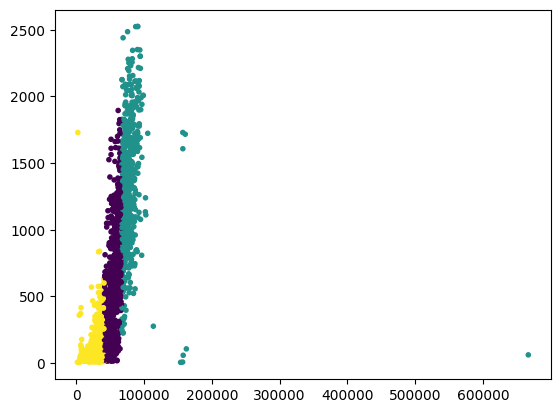

In [32]:
plt.scatter(df['Income'], df['Total_Spending'], c=labels, marker='.')
plt.show()

Income:   
* Most customers have an income of up to ~100k.
* There are some outliers (200k+, even 600k).
* Most data is concentrated in the 20k–100k range.

Total_Spending:   
* There are groups with very low spending (0–500).
* There are medium spending (500–1500).
* There are high spending (1500+).

Clusters:
* Yellow cluster: low income + low spending → "low-potential customers".   
* Purple cluster: middle spending regardless of income → "potential customers".
* Turquoise cluster: medium/high spending, wide income range → "active buyers".

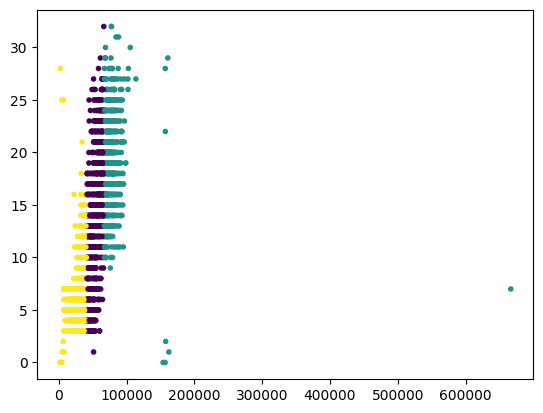

In [33]:
plt.scatter(df['Income'], df['NumPurchases'], c=labels, marker='.')
plt.show()

NumPurchases:
* There are many customers with low number of purchases (0–5).
* Some customers are active buyers (20–30 purchases).

Clusters:
* Yellow cluster: mostly low income + low number of purchases → “passive customers with low income”.
* Purple cluster: mixed income level but average number of purchases → “average activity, stable customers”.
* Turquoise cluster: medium and high income + higher number of purchases → “value customers, active buyers”.

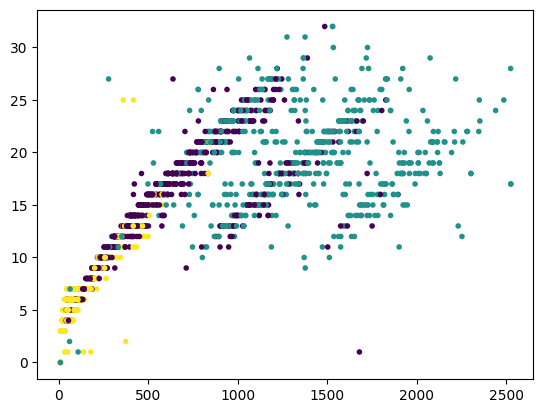

In [34]:
plt.scatter(df['Total_Spending'], df['NumPurchases'], c=labels, marker='.')
plt.show()

**Завдання 6**. Масштабуйте дані і побудуйте знову кластеризацію KMeans на 3 кластери і обчисліть метрику силуету. Опишіть порівняння з експериментом без масштабування значень.

In [35]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

kmeans_scaled = KMeans(n_clusters=3, random_state=42)
labels_scaled = kmeans_scaled.fit_predict(X_scaled)

silhouette_scaled = silhouette_score(X_scaled, labels_scaled, metric='euclidean')
print(f'Silhouette Coefficient for the Scaled Dataset Clusters: {silhouette_scaled:.2f}')

Silhouette Coefficient for the Scaled Dataset Clusters: 0.16


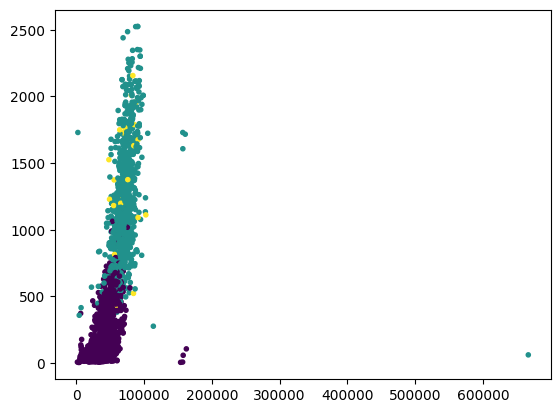

In [36]:
plt.scatter(df['Income'], df['Total_Spending'], c=labels_scaled, marker='.')
plt.show()

After scaling we have worst clustering and lower silhouette metric value.

**Завдання 7.** З візуалізацій на попередньому кроці ви могли побачити якісь викиди в даних. Опрацюйте викиди (можна видалити ці рядки або придумати інший спосіб).

In [37]:
num_cols = df.select_dtypes(include=['int64','float64']).columns.drop(['ID'])

In [38]:
num_cols

Index(['Year_Birth', 'Income', 'Kidhome', 'Teenhome', 'Recency', 'MntWines',
       'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts',
       'MntGoldProds', 'NumDealsPurchases', 'NumWebPurchases',
       'NumCatalogPurchases', 'NumStorePurchases', 'NumWebVisitsMonth',
       'AcceptedCmp3', 'AcceptedCmp4', 'AcceptedCmp5', 'AcceptedCmp1',
       'AcceptedCmp2', 'Complain', 'Z_CostContact', 'Z_Revenue', 'Response',
       'Education_2n Cycle', 'Education_Basic', 'Education_Graduation',
       'Education_Master', 'Education_PhD', 'Marital_Status_Divorced',
       'Marital_Status_Married', 'Marital_Status_Other',
       'Marital_Status_Single', 'Marital_Status_Together',
       'Marital_Status_Widow', 'Customer_Tenure', 'Total_Spending',
       'NumPurchases'],
      dtype='object')

In [39]:
outlier_summary = {}

for col in num_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    mask_outliers = ~df[col].between(lower, upper)
    outlier_count = mask_outliers.sum()

    outlier_summary[col] = {
        "outlier_count": outlier_count,
        "outlier_pct": round(outlier_count / len(df) * 100, 2),
        "min": df[col].min(),
        "max": df[col].max()
    }

outlier_df = pd.DataFrame(outlier_summary).T.sort_values("outlier_pct", ascending=False)
print(outlier_df)

                         outlier_count  outlier_pct     min       max
Education_PhD                    486.0        21.70     0.0       1.0
Marital_Status_Single            480.0        21.43     0.0       1.0
Education_Master                 370.0        16.52     0.0       1.0
Response                         334.0        14.91     0.0       1.0
MntSweetProducts                 248.0        11.07     0.0     263.0
Marital_Status_Divorced          232.0        10.36     0.0       1.0
MntFruits                        227.0        10.13     0.0     199.0
MntFishProducts                  223.0         9.96     0.0     259.0
MntGoldProds                     207.0         9.24     0.0     362.0
Education_2n Cycle               203.0         9.06     0.0       1.0
MntMeatProducts                  175.0         7.81     0.0    1725.0
AcceptedCmp4                     167.0         7.46     0.0       1.0
AcceptedCmp3                     163.0         7.28     0.0       1.0
AcceptedCmp5        

In [40]:
df_no_outliers = df.copy()

#### Year_Birth

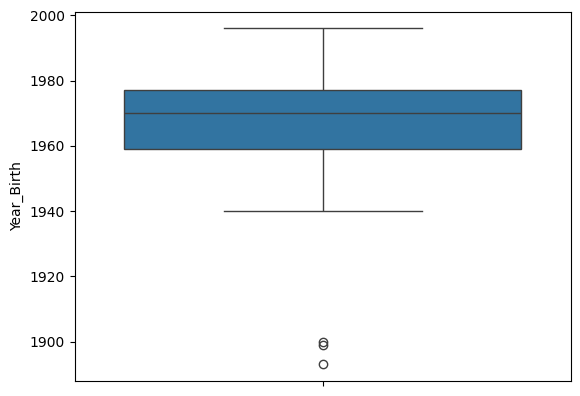

In [41]:
sns.boxplot(df.Year_Birth)
plt.show()

In [42]:
df['Year_Birth'].value_counts().sort_index()[:3]

,count
Year_Birth,
1893,1
1899,1
1900,1


We have 3 outliers for column `Year_Birth`

In [43]:
df['Year_Birth'].describe()

,Year_Birth
count,2240.000000
mean,1968.805804
std,11.984069
min,1893.000000
25%,1959.000000
50%,1970.000000
75%,1977.000000
max,1996.000000


In [44]:
median_year = df['Year_Birth'].median()
median_year

1970.0

Lets replace outliers for Year_Birth with its median value.

In [45]:
df_no_outliers.loc[df_no_outliers['Year_Birth'].isin([1893,1899,1900]), 'Year_Birth'] = median_year

#### Income

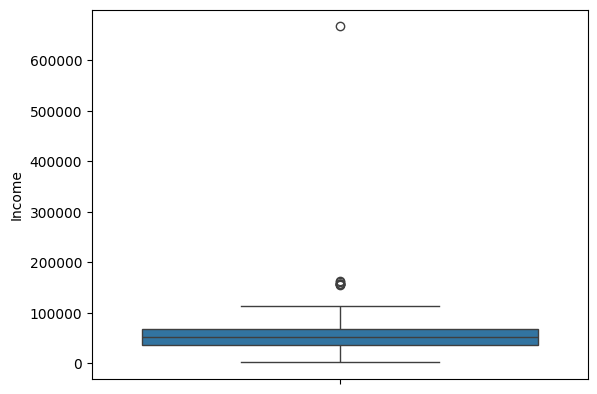

In [46]:
sns.boxplot(df.Income)
plt.show()

In [47]:
df['Income'].value_counts(dropna=False).sort_index().tail(8)

,count
Income,
153924.0,1
156924.0,1
157146.0,1
157243.0,1
157733.0,1
160803.0,1
162397.0,1
666666.0,1


We have 8 outliers for column `Income`

In [48]:
df['Income'].describe()

,Income
count,2240.000000
mean,52237.975446
std,25037.955891
min,1730.000000
25%,35538.750000
50%,51381.500000
75%,68289.750000
max,666666.000000


In [49]:
median_income = df['Income'].median()
median_income

51381.5

Lets replace outliers for Income with its median value.

In [50]:
df_no_outliers.loc[df_no_outliers['Income'].isin([153924,156924,157146,157243,157733,160803,162397,666666]), 'Income'] = median_income

**Завдання 8.** Виконайте Elbow method для пошуку оптимальної кількості кластерів та натренуйте KMeans з тою кількістю кластерів, яку Elbow method показав як оптимальну. Обчисліть метрику силуету. Візуалізуйте кластери. З яким набором даних (масштабованим чи ні) тут працювати - ваш вибір, можна зробити експеримент з обома.

In [51]:
X_no_outliers = df_no_outliers.drop(columns=['ID', 'Education', 'Marital_Status', 'Dt_Customer'])

In [52]:
def elbow_method(X_inputs, K):
  sum_of_squared_distances = []

  for k in K:
      model = KMeans(n_clusters=k, random_state=42).fit(X_inputs)
      sum_of_squared_distances.append(model.inertia_)

  plt.plot(K, sum_of_squared_distances, 'bx-')
  plt.xlabel('K values')
  plt.ylabel('Sum of Squared Distances')
  plt.title('Elbow Method')
  plt.show()

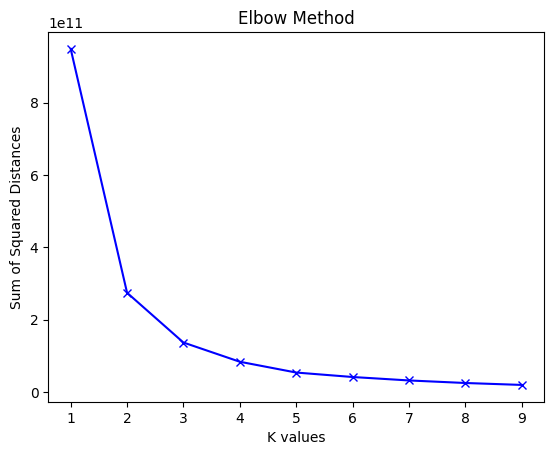

In [53]:
K = range(1, 10)
elbow_method(X_no_outliers, K)

Based on Elbow Method we see that 4 clusters is optimal value.

In [54]:
for k in [3, 4, 5, 6]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_no_outliers)

    silhouette_avg = silhouette_score(X_no_outliers, cluster_labels)
    print(f'For {k} clusters mean value of silhouette score is: {silhouette_avg:.2f}')

For 3 clusters mean value of silhouette score is: 0.55
For 4 clusters mean value of silhouette score is: 0.53
For 5 clusters mean value of silhouette score is: 0.54
For 6 clusters mean value of silhouette score is: 0.51


But silhouette score shows better results for 3 clusters.

In [55]:
scaler = StandardScaler()
X_scaled_no_outliers = scaler.fit_transform(X_no_outliers)

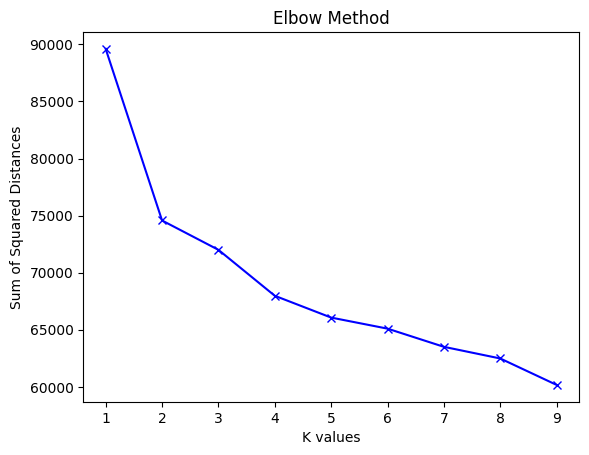

In [56]:
elbow_method(X_scaled_no_outliers, K)

In [57]:
for k in [3, 4, 5, 6, 7]:
    kmeans = KMeans(n_clusters=k, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled_no_outliers)

    silhouette_avg = silhouette_score(X_scaled_no_outliers, cluster_labels)
    print(f'For {k} clusters mean value of silhouette score is: {silhouette_avg:.2f}')

For 3 clusters mean value of silhouette score is: 0.18
For 4 clusters mean value of silhouette score is: 0.12
For 5 clusters mean value of silhouette score is: 0.06
For 6 clusters mean value of silhouette score is: 0.06
For 7 clusters mean value of silhouette score is: 0.07


The same result with scaled data, better result with 3 clusters.

**Завдання 9.** Використовуючи методи `scipy` `dendrogram, linkage, fcluster`
1. Побудуйте ієрархічну агломеративну кластеризацію з `single linkage` на даних невідмасштабованих, але з прибраним викидом.
2. Візуалізуйте дендрограму. При візуалізації обовʼязково задайте параметр `truncate_mode='lastp'` - це обріже дендрограму, без цього вона буде завелика, бо у нас тут даних суттєво більше, ніж в лекції.
3. Проаналізуйте дендрограму та побудуйте варіанти плоских кластеризацій з `fcluster` на 2 і 3 кластери. Візуалізуйте результати кожної з цих кластеризацій та зробіть висновок. Чи вважаєте ви якусь з цих кластеризацій вдалою? Що спостерігаєте з цих кластеризацій?
4. Порахуйте мерику силуету для цього методу кластеризації.

#### Single linkage

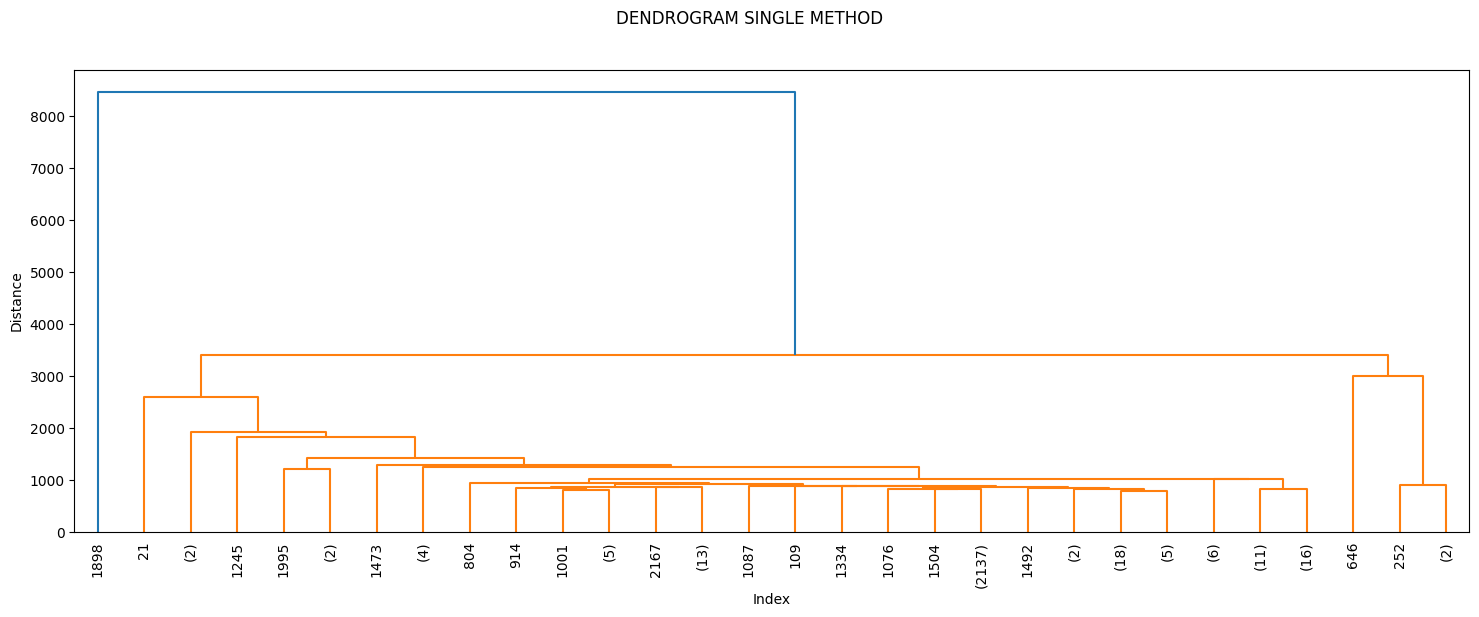

In [58]:
dist_sin = linkage(X_no_outliers, method='single')
plt.figure(figsize=(18,6))
dendrogram(dist_sin, leaf_rotation=90, truncate_mode='lastp')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle('DENDROGRAM SINGLE METHOD')
plt.show()

We can see 2 clusters, but first one has almost no values

In [59]:
df_no_outliers['2_clust'] = fcluster(dist_sin, 2, criterion='maxclust')
df_no_outliers['3_clust'] = fcluster(dist_sin, 3, criterion='maxclust')

In [60]:
df_no_outliers['2_clust'].value_counts()

,count
2_clust,
1,2239
2,1


In [61]:
df_no_outliers['3_clust'].value_counts()

,count
3_clust,
1,2235
2,4
3,1


The majority of values were identified as 1 cluster.

In [62]:
def cluster_visualization(df, title, x_col, y_col, hue_1, hue_2, hue_3=None):
  plt.figure(figsize=(10,8))
  plt.suptitle(title, fontsize=16)

  plt.subplot(3,1,1)
  plt.title(hue_1, fontsize=12)
  sns.scatterplot(x=x_col, y=y_col, data=df, hue=hue_1, s=20)

  plt.subplot(3,1,2)
  plt.title(hue_2, fontsize=12)
  sns.scatterplot(x=x_col, y=y_col, data=df, hue=hue_2, s=20)

  if(hue_3):
    plt.subplot(3,1,3)
    plt.title(hue_3, fontsize=12)
    sns.scatterplot(x=x_col, y=y_col, data=df, hue=hue_3, s=20)

  plt.tight_layout();

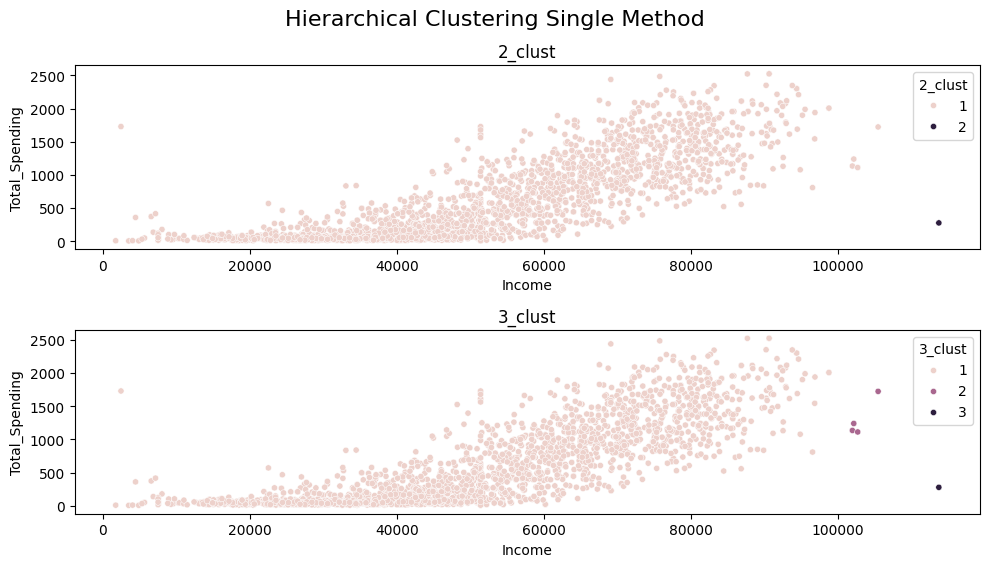

In [63]:
cluster_visualization(df_no_outliers, 'Hierarchical Clustering Single Method', 'Income', 'Total_Spending', '2_clust', '3_clust')

In [64]:
silhouette_2_clust = silhouette_score(X_no_outliers, df_no_outliers['2_clust'])
print(f'For 2 clusters mean value of silhouette score is: {silhouette_2_clust:.2f}')

silhouette_3_clust = silhouette_score(X_no_outliers, df_no_outliers['3_clust'])
print(f'For 3 clusters mean value of silhouette score is: {silhouette_3_clust:.2f}')

For 2 clusters mean value of silhouette score is: 0.56
For 3 clusters mean value of silhouette score is: 0.45


Based on silhouette score, we didn't get better results.

**Завдання 10.**
1. Використайте метод кластеризації, який ми не використовували в попередніх завданнях цього ДЗ (може бути ієрархічна кластеризація з іншим способом звʼязності або інші методи sklearn).
2. Порахуйте мер=трику силуету і візуалізуйте результат кластеризації. Зробіть висновок про те, чи могла б ця кластеризація бути корисною?

#### Complete linkage

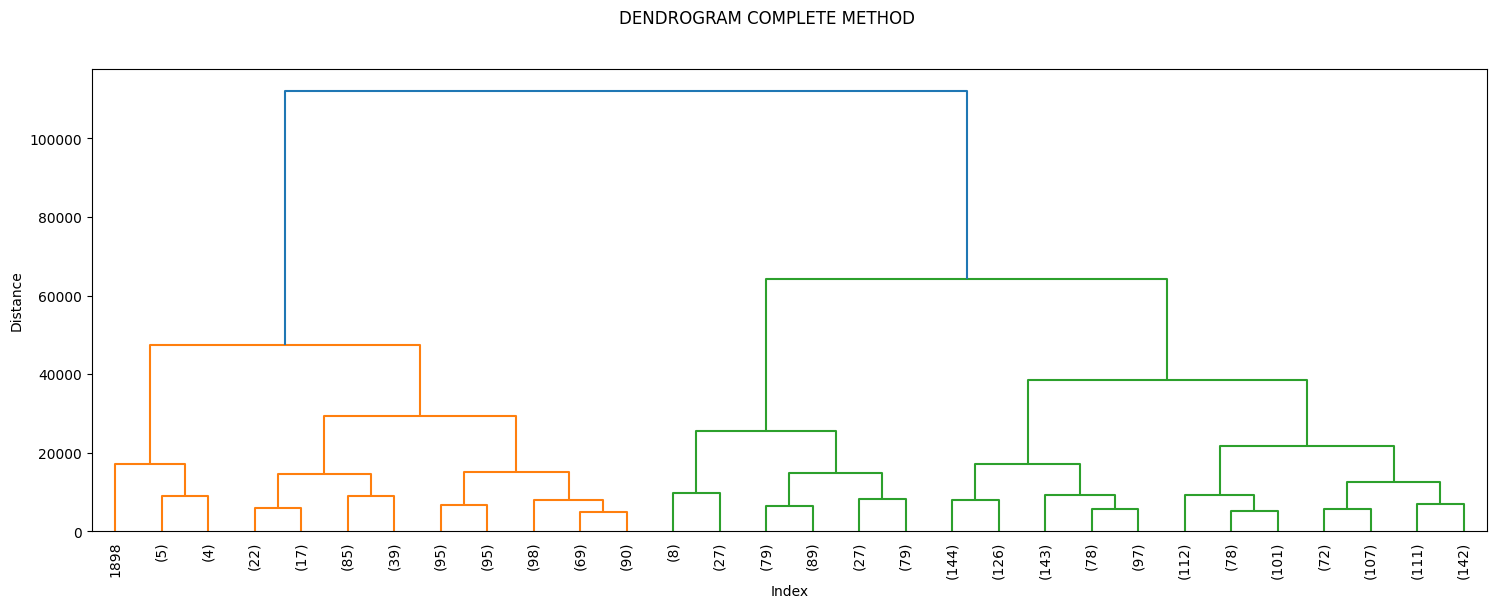

In [65]:
dist_comp = linkage(X_no_outliers, method='complete')

plt.figure(figsize=(18,6))
dendrogram(dist_comp, leaf_rotation=90, truncate_mode='lastp')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle('DENDROGRAM COMPLETE METHOD')
plt.show()

Here we can see better distribution of data.

In [66]:
df_no_outliers['2_clust_CM'] = fcluster(dist_comp, 2, criterion='maxclust')
df_no_outliers['3_clust_CM'] = fcluster(dist_comp, 3, criterion='maxclust')
df_no_outliers['4_clust_CM'] = fcluster(dist_comp, 4, criterion='maxclust')

In [67]:
for k in [2, 3, 4]:
    silhouette_avg = silhouette_score(X_no_outliers, df_no_outliers[f'{k}_clust_CM'])
    print(f'For {k} clusters mean value of silhouette score is: {silhouette_avg:.2f}')

For 2 clusters mean value of silhouette score is: 0.52
For 3 clusters mean value of silhouette score is: 0.45
For 4 clusters mean value of silhouette score is: 0.41


Silhouette score is better for 2 clusters.

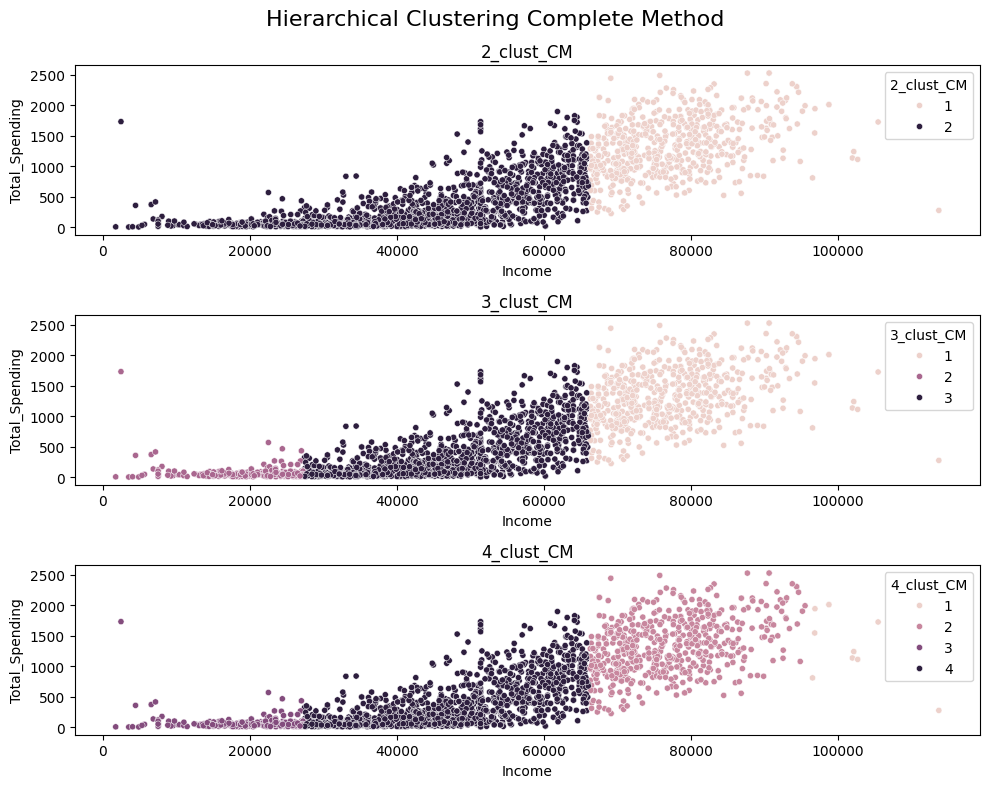

In [68]:
cluster_visualization(df_no_outliers, 'Hierarchical Clustering Complete Method', 'Income', 'Total_Spending', '2_clust_CM', '3_clust_CM', '4_clust_CM')

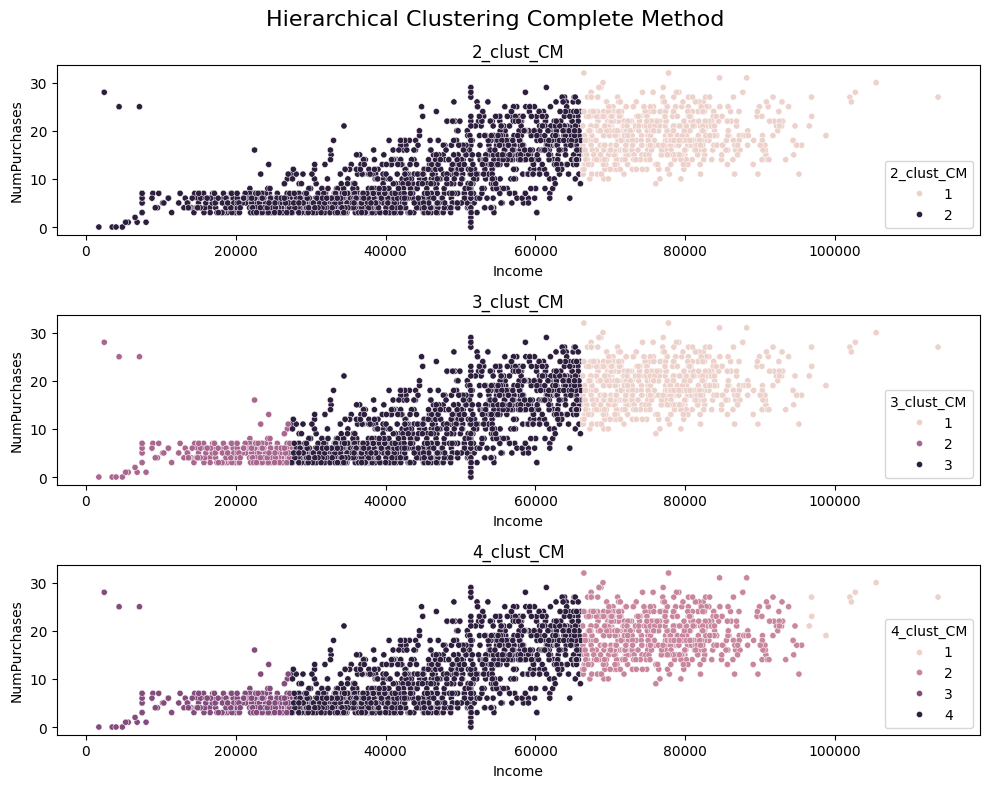

In [69]:
cluster_visualization(df_no_outliers, 'Hierarchical Clustering Complete Method', 'Income', 'NumPurchases', '2_clust_CM', '3_clust_CM', '4_clust_CM')

#### Ward linkage

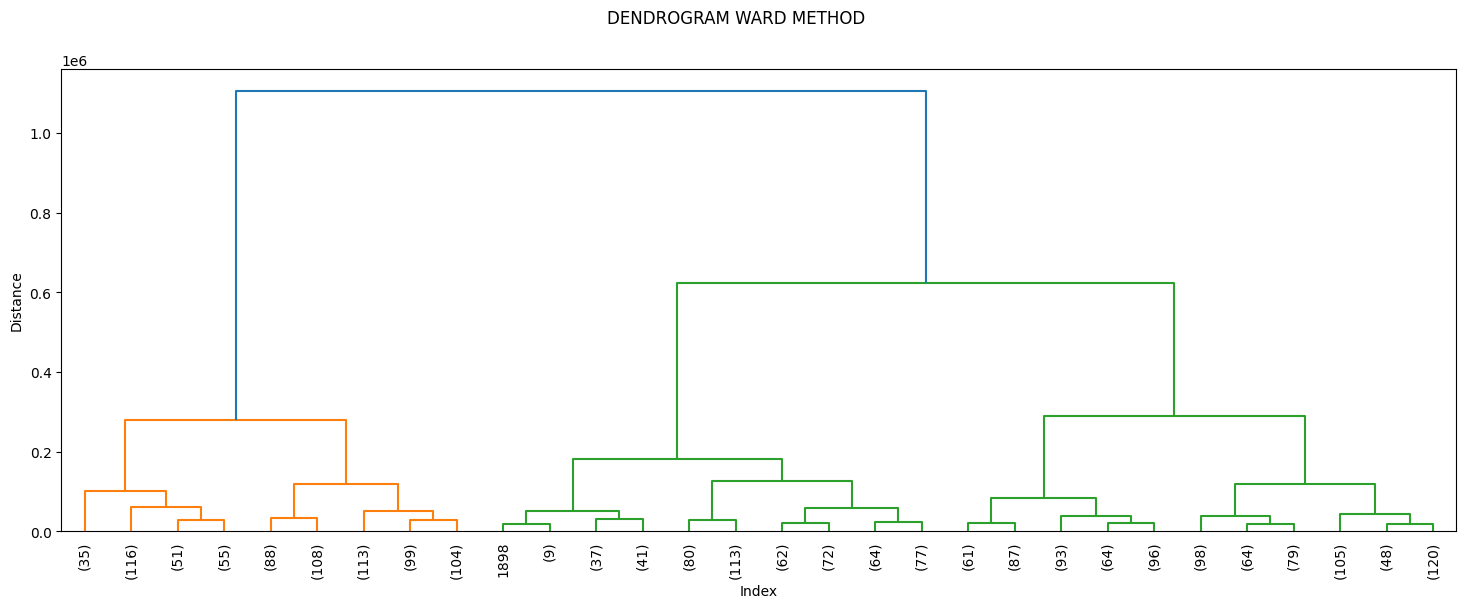

In [70]:
dist_ward = linkage(X_no_outliers, method='ward')

plt.figure(figsize=(18,6))
dendrogram(dist_ward, leaf_rotation=90, truncate_mode='lastp')
plt.xlabel('Index')
plt.ylabel('Distance')
plt.suptitle('DENDROGRAM WARD METHOD')
plt.show()

In [71]:
df_no_outliers['2_clust_WD'] = fcluster(dist_ward, 2, criterion='maxclust')
df_no_outliers['3_clust_WD'] = fcluster(dist_ward, 3, criterion='maxclust')
df_no_outliers['4_clust_WD'] = fcluster(dist_ward, 4, criterion='maxclust')

In [72]:
for k in [2, 3, 4]:
    silhouette_avg = silhouette_score(X_no_outliers, df_no_outliers[f'{k}_clust_WD'])
    print(f'For {k} clusters mean value of silhouette score is: {silhouette_avg:.2f}')

For 2 clusters mean value of silhouette score is: 0.55
For 3 clusters mean value of silhouette score is: 0.55
For 4 clusters mean value of silhouette score is: 0.49


We received good result for 3 clusters.

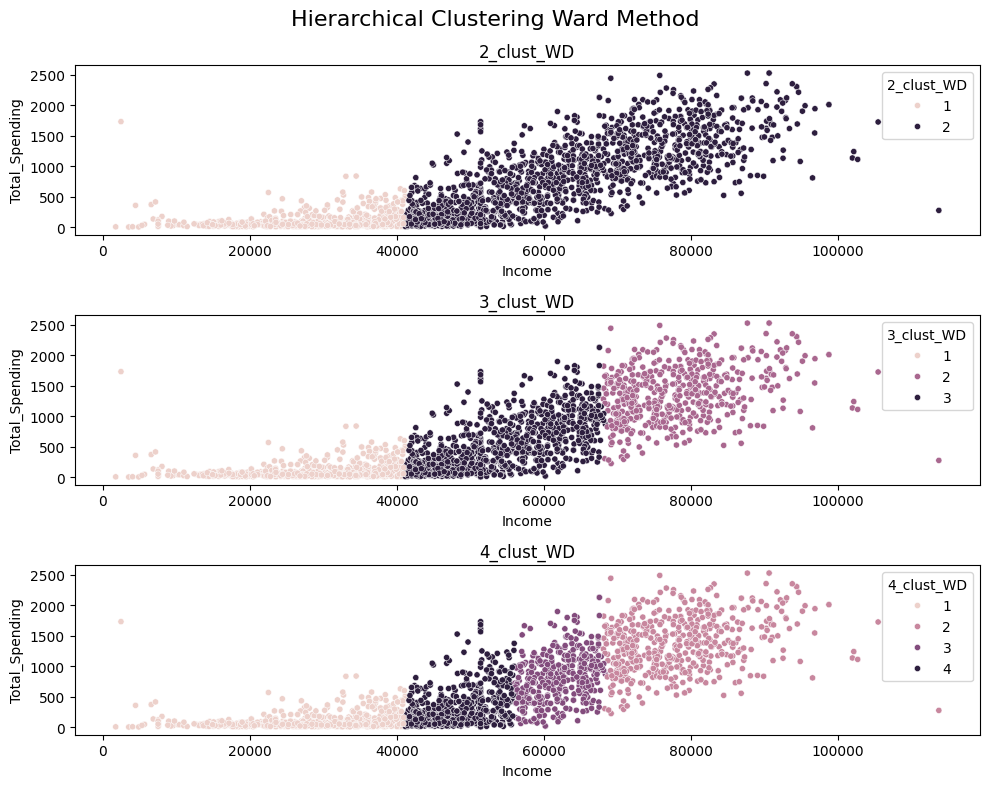

In [73]:
cluster_visualization(df_no_outliers, 'Hierarchical Clustering Ward Method', 'Income', 'Total_Spending', '2_clust_WD', '3_clust_WD', '4_clust_WD')

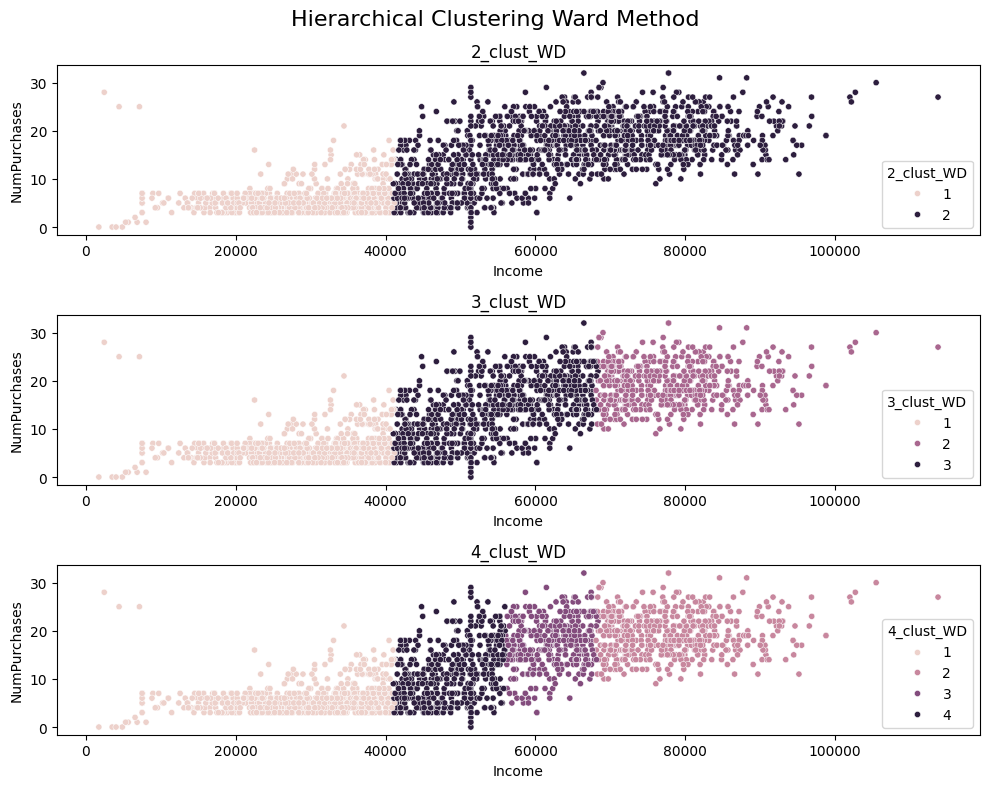

In [74]:
cluster_visualization(df_no_outliers, 'Hierarchical Clustering Ward Method', 'Income', 'NumPurchases', '2_clust_WD', '3_clust_WD', '4_clust_WD')

Ward linkage showed better result.

#### DBSCAN

In [75]:
dbscan = DBSCAN(eps=10, min_samples=10)
dbscan.fit(X_scaled_no_outliers)
labels_dbscan = dbscan.labels_
print(labels_dbscan)

[0 0 0 ... 0 0 0]


In [76]:
n_clusters_ = len(set(labels_dbscan)) - (1 if -1 in labels_dbscan else 0)
n_noise_ = list(labels_dbscan).count(-1)

print('Estimated number of clusters: %d' % n_clusters_)
print('Estimated number of noise points: %d' % n_noise_)

s = silhouette_score(X_scaled_no_outliers, labels_dbscan)
print(f'Silhouette Coefficient for the Dataset Clusters: {s:.2f}')

Estimated number of clusters: 2
Estimated number of noise points: 11
Silhouette Coefficient for the Dataset Clusters: 0.37


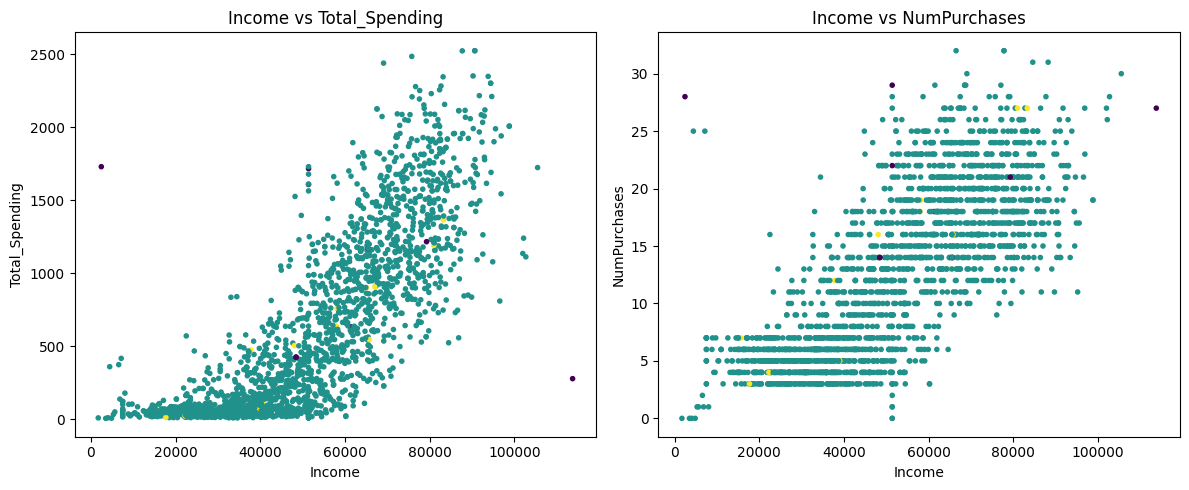

In [77]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharex=True)
axes[0].scatter(df_no_outliers['Income'], df_no_outliers['Total_Spending'], c=labels_dbscan, marker='.')
axes[0].set_title('Income vs Total_Spending')
axes[0].set_xlabel('Income');
axes[0].set_ylabel('Total_Spending')

axes[1].scatter(df_no_outliers['Income'], df_no_outliers['NumPurchases'], c=labels_dbscan, marker='.')
axes[1].set_title('Income vs NumPurchases')
axes[1].set_xlabel('Income');
axes[1].set_ylabel('NumPurchases')

plt.tight_layout()
plt.show()

DBSCAN method showed worse results.

#### KMeans without outliers

Silhouette Coefficient for the Dataset Clusters: 0.55


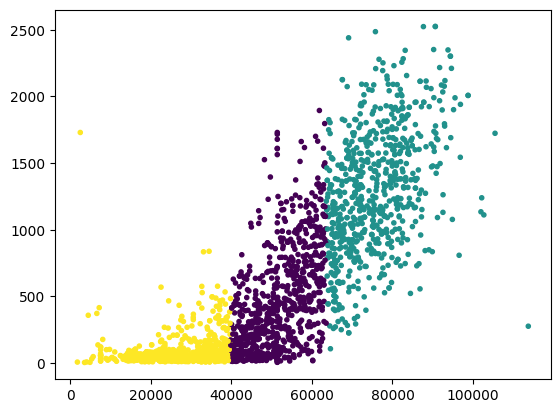

In [78]:
kmeans_no_outliers = KMeans(n_clusters=3, random_state=42)
kmeans_no_outliers.fit(X_no_outliers)

labels_no_outliers = kmeans_no_outliers.predict(X_no_outliers)
slh = silhouette_score(X_no_outliers, labels_no_outliers, metric='euclidean')
print(f'Silhouette Coefficient for the Dataset Clusters: {slh:.2f}')
plt.scatter(df_no_outliers['Income'], df_no_outliers['Total_Spending'], c=labels_no_outliers, marker='.')
plt.show()

KMeans and Agglomerative Hierarchical Clustering with Ward's method showed best results.

#### Silhouette metrics analysis

For n_clusters = 2 silhouette score is: 0.5998
For n_clusters = 3 silhouette score is: 0.5517
For n_clusters = 4 silhouette score is: 0.5324


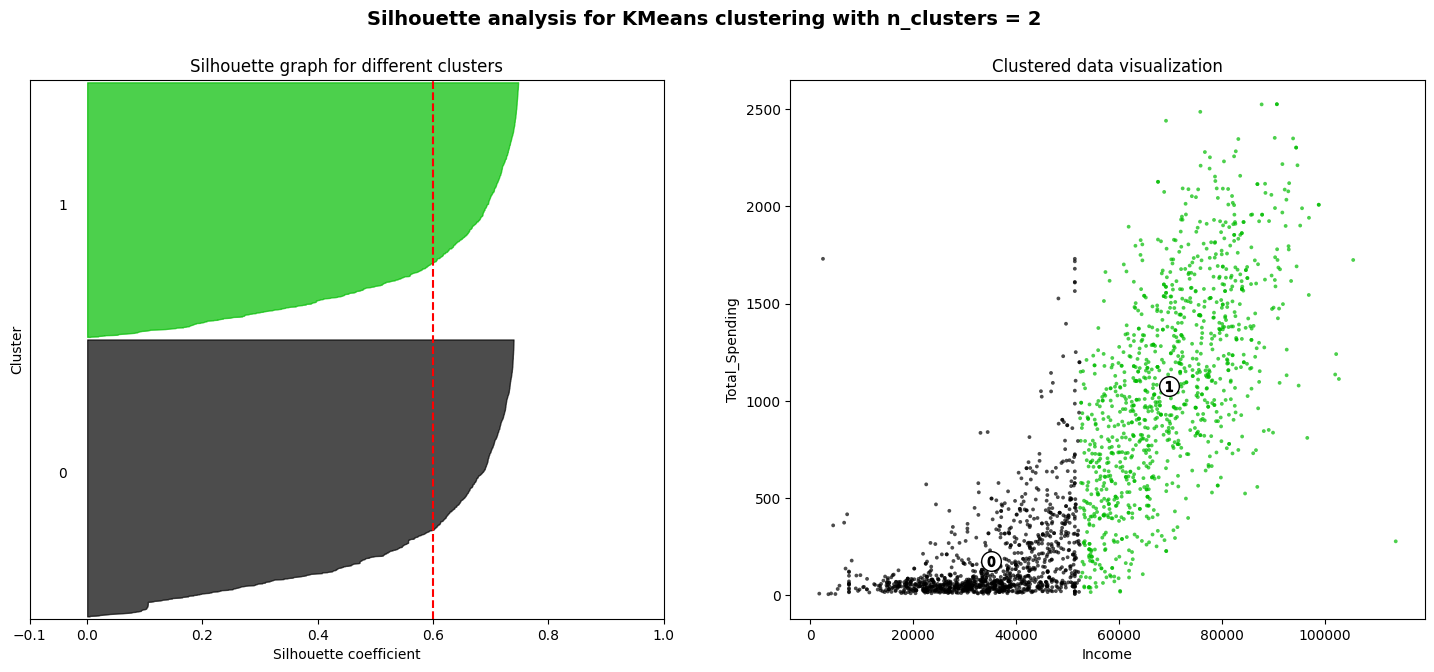

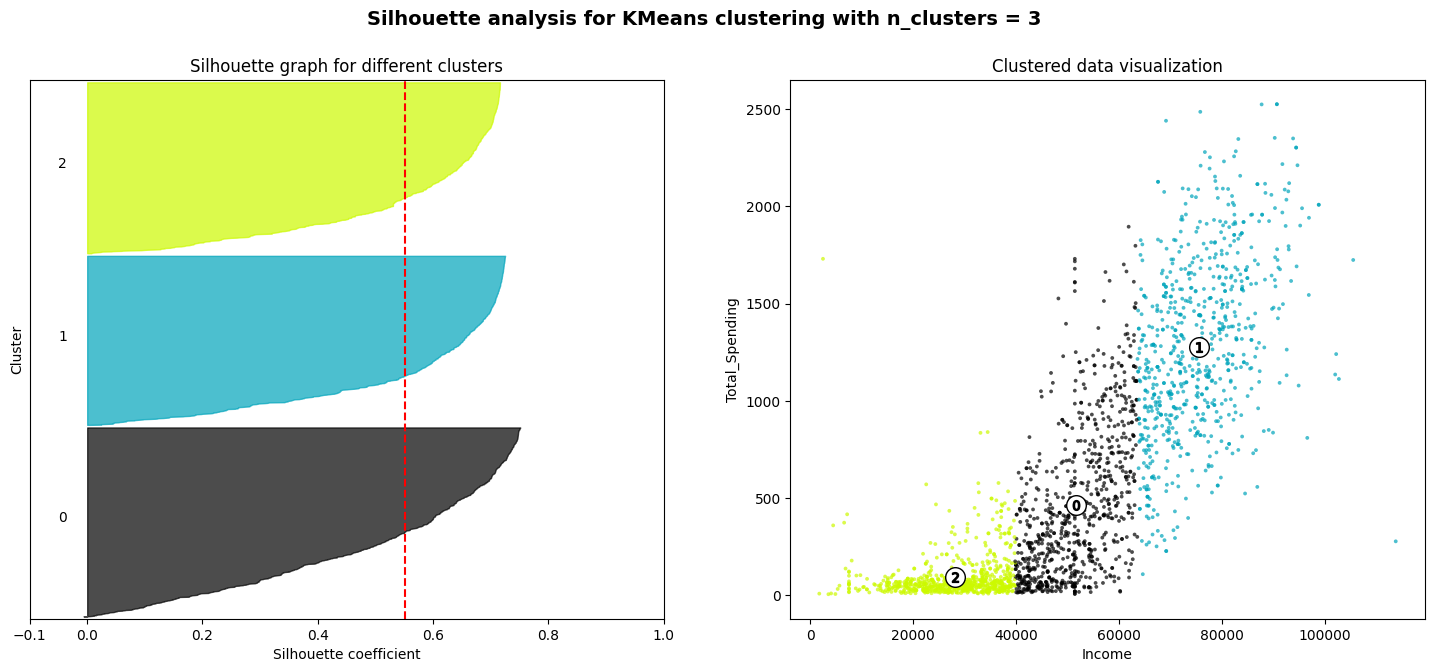

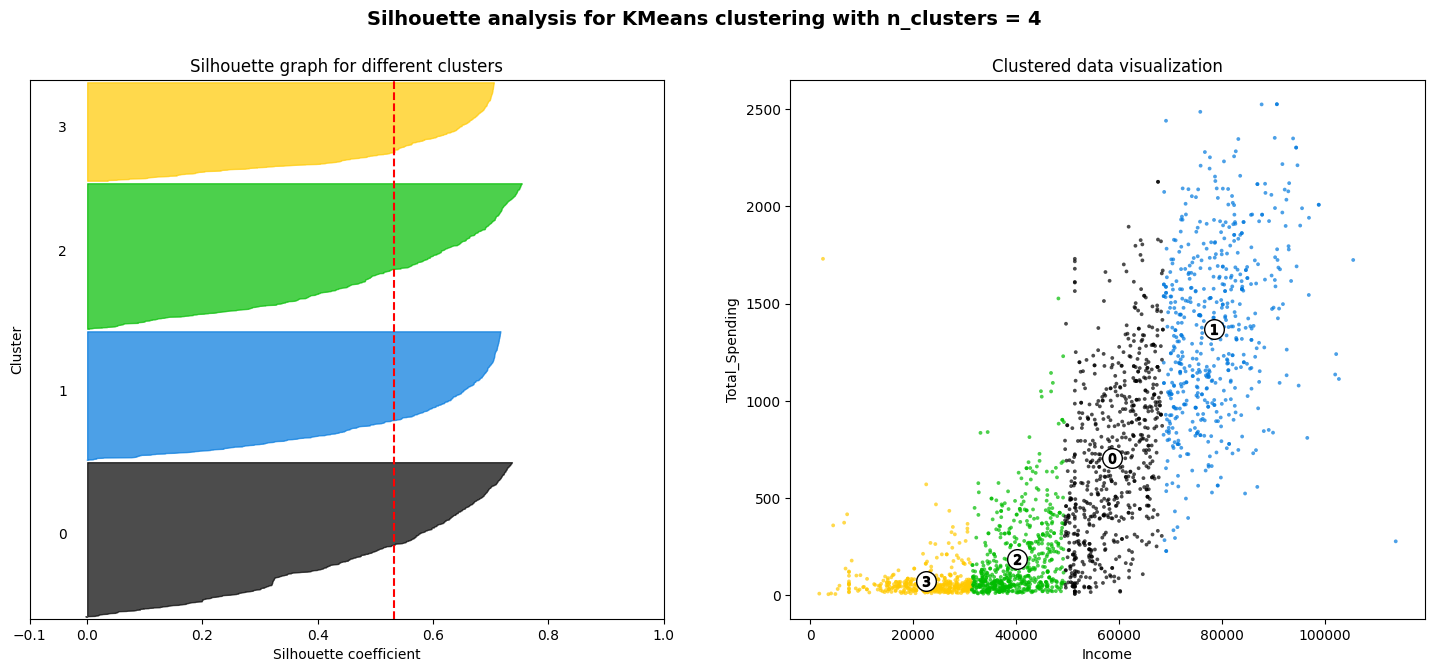

In [79]:
range_n_clusters = [2, 3, 4]

for n_clusters in range_n_clusters:
    fig, (ax1, ax2) = plt.subplots(1, 2)
    fig.set_size_inches(18, 7)

    # first graph
    ax1.set_xlim([-0.1, 1])
    ax1.set_ylim([0, len(X_no_outliers) + (n_clusters + 1) * 10])

    clusterer = KMeans(n_clusters=n_clusters, random_state=42, n_init='auto')
    cluster_labels = clusterer.fit_predict(X_no_outliers)
    silhouette_avg = silhouette_score(X_no_outliers, cluster_labels)
    print(
        "For n_clusters =",
        n_clusters,
        "silhouette score is:",
        f"{silhouette_avg:.4f}"
    )

    sample_silhouette_values = silhouette_samples(X_no_outliers, cluster_labels)

    y_lower = 10
    for i in range(n_clusters):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()

        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(
            np.arange(y_lower, y_upper),
            0,
            ith_cluster_silhouette_values,
            facecolor=color,
            edgecolor=color,
            alpha=0.7,
        )
        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax1.set_title("Silhouette graph for different clusters")
    ax1.set_xlabel("Silhouette coefficient")
    ax1.set_ylabel("Cluster")

    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")

    ax1.set_yticks([])
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])

    # second graph
    colors = cm.nipy_spectral(cluster_labels.astype(float) / n_clusters)
    ax2.scatter(X_no_outliers['Income'], X_no_outliers['Total_Spending'], marker=".", s=30, lw=0, alpha=0.7, c=colors, edgecolor="k")

    ix_income = X_no_outliers.columns.get_loc('Income')
    ix_total  = X_no_outliers.columns.get_loc('Total_Spending')
    centers = clusterer.cluster_centers_

    ax2.scatter(centers[:, ix_income], centers[:, ix_total], marker="o", c="white", alpha=1, s=200, edgecolor="k")

    for i, c in enumerate(centers):
        ax2.scatter(c[ix_income], c[ix_total], marker="$%d$" % i, alpha=1, s=50, edgecolor="k")

    ax2.set_title("Clustered data visualization")
    ax2.set_xlabel("Income")
    ax2.set_ylabel("Total_Spending")

    plt.suptitle(
        "Silhouette analysis for KMeans clustering with n_clusters = %d"
        % n_clusters,
        fontsize=14,
        fontweight="bold",
    )

plt.show()

Conclusion:

* 2 clusters → best silhouette, but too simple for business use.
* 3 clusters → strong silhouette and clear, interpretable customer groups.
* 4 clusters → weaker silhouettes, more complex, not much extra insight.

Best choice: 3 clusters.